In [344]:
dados_f1 = 'https://raw.githubusercontent.com/Mirlaa/s-ries-temporais-statsmodels/main/Dados/Temperatura_mensal_F1.csv'
dados_f2 = 'https://raw.githubusercontent.com/Mirlaa/s-ries-temporais-statsmodels/main/Dados/Temperatura_mensal_F2.csv'
dados_f3 = 'https://raw.githubusercontent.com/Mirlaa/s-ries-temporais-statsmodels/main/Dados/Temperatura_mensal_F3.csv'

In [345]:
import pandas as pd
import matplotlib.pyplot as plt

# Farm I

![Alt text: Imagem de uma fazenda com plantações de uvas](https://github.com/Mirlaa/s-ries-temporais-statsmodels/blob/main/imagens/Fazenda%201.png?raw=true)

In [346]:
df_f1 = pd.read_csv(dados_f1)
df_f1

,DATA,TEMP
0,1963-05-01,23.11
1,1963-06-01,24.20
2,1963-07-01,25.37
3,1963-08-01,23.86
4,1963-09-01,23.03
...,...,...
727,2023-12-01,19.49
728,2024-01-01,19.28
729,2024-02-01,19.73
730,2024-03-01,20.44


In [347]:
df_f1['DATA'] = pd.to_datetime(df_f1['DATA'], format='%Y-%m-%d')
df_f1.set_index(['DATA'], inplace=True, drop=True)
df_f1

,TEMP
DATA,
1963-05-01,23.11
1963-06-01,24.20
1963-07-01,25.37
1963-08-01,23.86
1963-09-01,23.03
...,...
2023-12-01,19.49
2024-01-01,19.28
2024-02-01,19.73


<Axes: xlabel='DATA'>

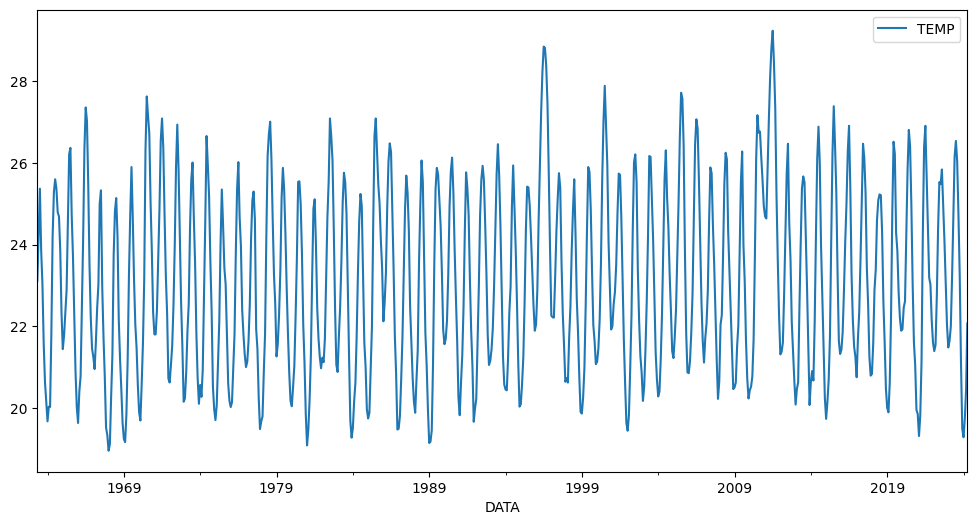

In [348]:
df_f1.plot(figsize=(12,6))

## Naive Model

A naive model in time series is one of the simplest forecasting methods, based on the assumption that the best predictor for any future point is the most recent available value in the series. This means that the forecast for all future points will be equal to the last observed value.

In [349]:
df_f1.shift(1)

,TEMP
DATA,
1963-05-01,NaN
1963-06-01,23.11
1963-07-01,24.20
1963-08-01,25.37
1963-09-01,23.86
...,...
2023-12-01,21.11
2024-01-01,19.49
2024-02-01,19.28


## Evaluating Stationarity  

Stationarity is a key concept in time series analysis, as many forecasting models assume that the data is stationary (i.e., its statistical properties do not change over time). A stationary time series has:  

- **Constant mean** (no trend)  
- **Constant variance** (no heteroskedasticity)  
- **Autocorrelation structure** that does not depend on time  

### Methods to Evaluate Stationarity:  

1. **Visual Inspection (Time Series Plot)**  
   - Plot the data and check for trends, seasonality, or changing variance.  
   - A stationary series should fluctuate around a constant mean with stable variance.  

2. **Summary Statistics**  
   - Split the series into multiple segments and compare means and variances.  
   - If they differ significantly, the series may be non-stationary.  

3. **Augmented Dickey-Fuller (ADF) Test**  
   - A formal statistical test where:  
     - **Null Hypothesis (H₀):** The series has a unit root (non-stationary).  
     - **Alternative Hypothesis (H₁):** The series is stationary.  
   - If the **p-value ≤ significance level (e.g., 0.05)**, reject H₀ (stationary).  

4. **Kwiatkowski-Phillips-Schmidt-Shin (KPSS) Test**  
   - Another test where:  
     - **H₀:** The series is stationary (around a trend).  
     - **H₁:** The series has a unit root (non-stationary).  
   - If **p-value < significance level**, reject H₀ (non-stationary).  

5. **Autocorrelation Function (ACF) Plot**  
   - A stationary series should show ACF decaying rapidly to zero.  
   - Slow decay suggests non-stationarity.  

### How to Handle Non-Stationary Data:  
- **Differencing** (subtract previous values to remove trends).  
- **Transformation** (log, square root) to stabilize variance.  
- **Decomposition** (remove trend and seasonality).  

In [350]:
from statsmodels.tsa.stattools import adfuller, kpss

def estac(df):

  adf = adfuller(df)
  print(f'Valor-p do Teste ADF: {adf[1]:.4f}')
  if adf[1] > 0.05:
    print('Não rejeitar a Hipótese Nula: a série não é estacionária\n')
  else:
    print('Rejeitar a Hipótese Nula: a série é estacionária\n')

  kpss_saida = kpss(df)
  print(f'Valor-p do Teste KPSS: {kpss_saida[1]:.4f}')
  if kpss_saida[1] > 0.05:
    print('Não rejeitar a Hipótese Nula: a série é estacionária\n')
  else:
    print('Rejeitar a Hipótese Nula: a série não é estacionária\n')

In [351]:
estac(df_f1)

Valor-p do Teste ADF: 0.0000
Rejeitar a Hipótese Nula: a série é estacionária

Valor-p do Teste KPSS: 0.0798
Não rejeitar a Hipótese Nula: a série é estacionária



In [352]:
divisao = int(len(df_f1)*0.70)

treino = df_f1.iloc[:divisao].asfreq('MS')
teste = df_f1.iloc[divisao:].asfreq("MS")

## Autoregressive (AR) Model  

The **Autoregressive (AR) model** is a fundamental time series forecasting method that predicts future values based on a linear combination of past observations. It assumes that the current value depends on its own previous values plus some random noise.  

### Mathematical Formulation  
An AR model of order *p* (denoted as **AR(p)**) is defined as:  

\[
X_t = c + \phi_1 X_{t-1} + \phi_2 X_{t-2} + \dots + \phi_p X_{t-p} + \epsilon_t
\]  

Where:  
- \(X_t\) = Value at time \(t\)  
- \(c\) = Constant (intercept)  
- \(\phi_1, \phi_2, \dots, \phi_p\) = Coefficients of past values  
- \(\epsilon_t\) = White noise (random error)  
- \(p\) = Lag order (number of past observations used)  

### Key Assumptions  
1. **Stationarity**: The time series should be stationary (no trends or seasonality).  
2. **No Autocorrelation in Residuals**: Errors (\(\epsilon_t\)) should be random (no patterns).  

### How to Determine the Order (p)? 
- **Partial Autocorrelation Function (PACF) Plot**:  
  - Helps identify the optimal lag order (*p*).  
  - The lag where PACF cuts off (drops to near zero) suggests the AR order.  

### Estimation & Model Selection 
1. **Fit AR models** with different *p* values.  
2. **Compare models** using metrics like:  
   - **AIC (Akaike Information Criterion)**  
   - **BIC (Bayesian Information Criterion)**  
   - **Log-Likelihood**  
3. **Check residuals** for randomness (no autocorrelation).  

### When to Use AR Model?  
✔️ When past values influence future values (e.g., stock prices, temperature).  
✔️ When data is **stationary** (if not, apply differencing first → ARIMA).  
❌ Not suitable for **trending** or **seasonal** data (use ARIMA or SARIMA instead).  

### Limitations  
- Assumes linear dependence on past values.  
- Struggles with external factors (use ARX or VAR for multivariate cases).  

Would you like help implementing an AR model on your dataset?

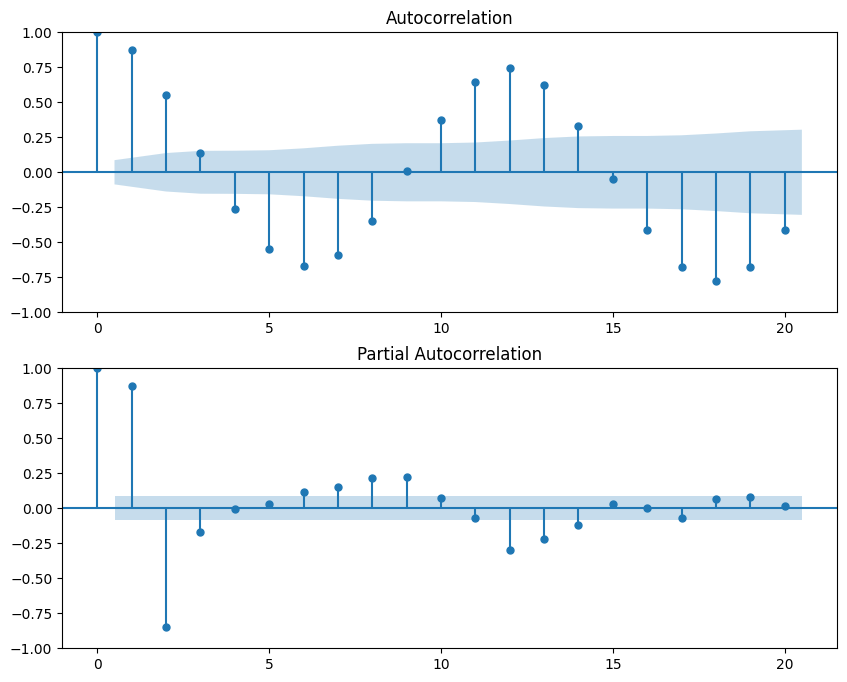

In [353]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig = plt.figure(figsize=(10,8))

ax1 = fig.add_subplot(211)
fig = plot_acf(treino, lags=20, ax=ax1)

ax2 = fig.add_subplot(212)
fig = plot_pacf(treino, lags=20, ax=ax2)

In [354]:
from statsmodels.tsa.ar_model import AutoReg

ar_mod = AutoReg(treino,14, old_names=False)
ar_res = ar_mod.fit()
print(ar_res.summary())

                            AutoReg Model Results                             
Dep. Variable:                   TEMP   No. Observations:                  512
Model:                    AutoReg(14)   Log Likelihood                -317.490
Method:               Conditional MLE   S.D. of innovations              0.458
Date:                Mon, 05 May 2025   AIC                            666.981
Time:                        15:08:08   BIC                            734.350
Sample:                    07-01-1964   HQIC                           693.421
                         - 12-01-2005                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          5.0973      0.649      7.855      0.000       3.825       6.369
TEMP.L1        1.1971      0.044     27.078      0.000       1.110       1.284
TEMP.L2       -0.3092      0.069     -4.470      0.0

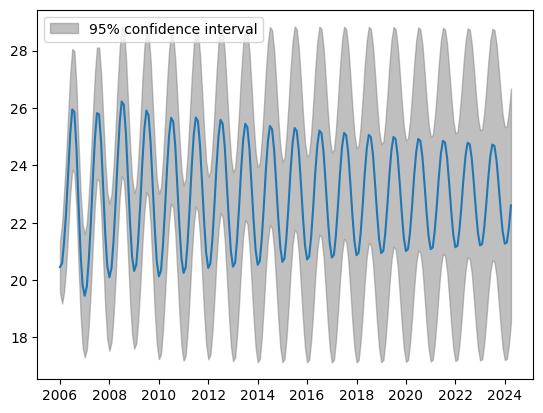

In [355]:
from statsmodels.tsa.ar_model import AutoRegResults

mod_result = AutoRegResults(ar_mod, ar_res.params, ar_res.cov_params())

fig = mod_result.plot_predict(len(treino), len(treino)+len(teste)-1)

In [356]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

def plot_prev(treino, teste, mod, nome_mod = ''):

  previsoes = mod.predict(len(treino), len(treino) + len(teste)-1, dynamic=False)

  plt.figure(figsize=(12, 5))

  plt.plot(teste.index, teste, label='Esperado')
  plt.plot(previsoes.index, previsoes, label='Previsto', color='red')

  plt.title(f'Previsão modelo {nome_mod}')
  plt.ylabel('Temperatura')
  plt.legend()
  plt.show()

  print('\nMétricas:\n')
  mae = mean_absolute_error(teste, previsoes)
  print(f'MAE: {mae}')

  mse = mean_squared_error(teste, previsoes)
  print(f'MSE: {mse}')

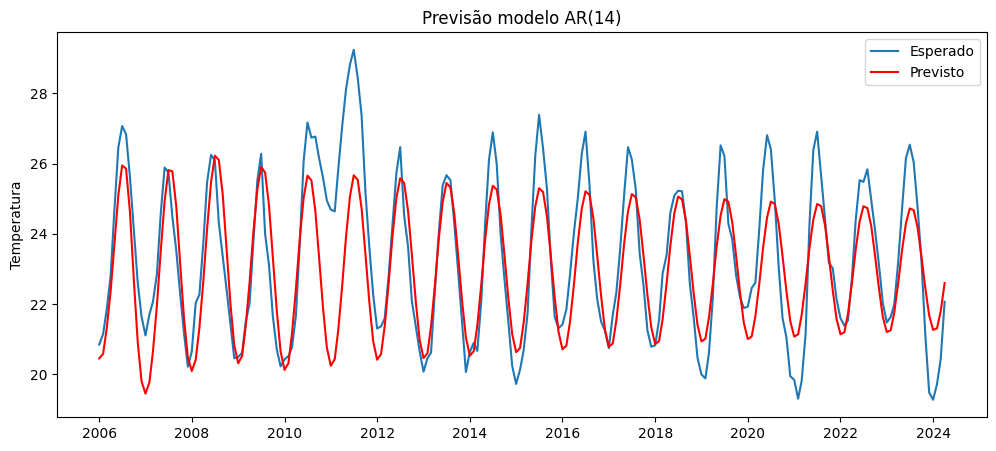


Métricas:

MAE: 1.042706398397126
MSE: 1.8489038142161127


In [357]:
plot_prev(treino, teste, ar_res, 'AR(14)')

### Parameters

In [358]:
from statsmodels.tsa.ar_model import ar_select_order
ar_selecao = ar_select_order(treino, 35, old_names=False, ic='aic')

In [359]:
ar_selecao.ar_lags

[1,
 2,
 3,
 4,
 5,
 6,
 7,
 8,
 9,
 10,
 11,
 12,
 13,
 14,
 15,
 16,
 17,
 18,
 19,
 20,
 21,
 22,
 23,
 24,
 25,
 26,
 27,
 28,
 29,
 30,
 31,
 32,
 33,
 34]

In [360]:
ar_sel_res = ar_selecao.model.fit()
print(ar_sel_res.summary())

                            AutoReg Model Results                             
Dep. Variable:                   TEMP   No. Observations:                  512
Model:                    AutoReg(34)   Log Likelihood                -265.842
Method:               Conditional MLE   S.D. of innovations              0.422
Date:                Mon, 05 May 2025   AIC                            603.684
Time:                        15:08:08   BIC                            753.790
Sample:                    03-01-1966   HQIC                           662.698
                         - 12-01-2005                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          4.4648      1.091      4.092      0.000       2.326       6.603
TEMP.L1        1.1355      0.045     25.067      0.000       1.047       1.224
TEMP.L2       -0.2017      0.068     -2.958      0.0

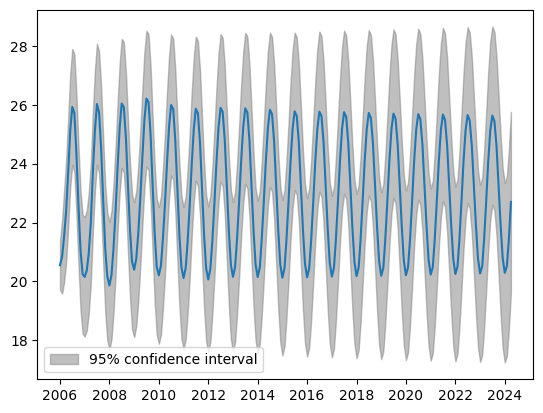

In [361]:
fig = ar_sel_res.plot_predict(len(treino), len(treino) + len(teste)-1)

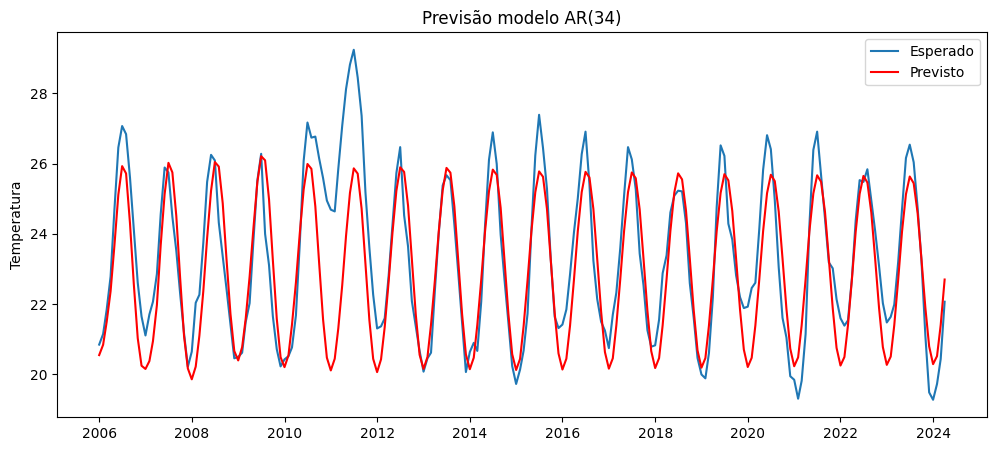


Métricas:

MAE: 0.9474776896244423
MSE: 1.6610673113344863


In [362]:
plot_prev(treino,teste,ar_sel_res,'AR(34)')

# Farm II

![Alt text: Imagem de uma fazenda com plantações de tomates](https://github.com/Mirlaa/s-ries-temporais-statsmodels/blob/main/imagens/Fazenda%202.png?raw=true)

In [363]:
df_f2 = pd.read_csv(dados_f2)
df_f2

,DATA,TEMP
0,1966-02-01,23.436171
1,1966-03-01,29.787675
2,1966-04-01,25.626345
3,1966-05-01,22.958315
4,1966-06-01,19.513770
...,...,...
694,2023-12-01,15.033869
695,2024-01-01,17.323596
696,2024-02-01,22.818941
697,2024-03-01,29.429283


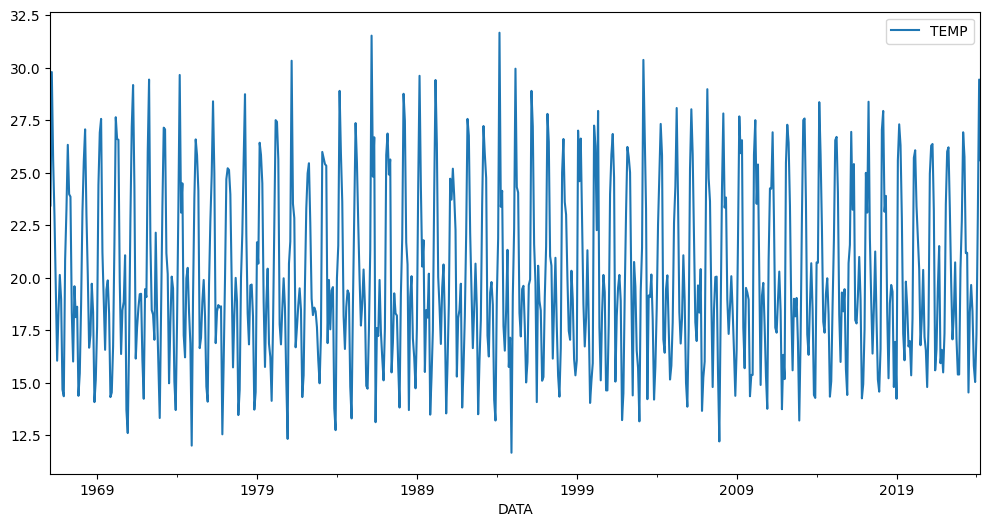

In [364]:
df_f2['DATA'] = pd.to_datetime(df_f2['DATA'], format='%Y-%m-%d')
df_f2.set_index(['DATA'], inplace=True, drop=True)
fig = df_f2.plot(figsize=(12, 6))

In [365]:
estac(df_f2)

Valor-p do Teste ADF: 0.0000
Rejeitar a Hipótese Nula: a série é estacionária

Valor-p do Teste KPSS: 0.1000
Não rejeitar a Hipótese Nula: a série é estacionária



In [366]:
divisao = int(len(df_f2)*0.8)

treino = df_f2.iloc[:divisao].asfreq('MS')
teste = df_f2.iloc[divisao:].asfreq('MS')

### **Building a Predictive Model**  

A predictive model is a statistical or machine learning approach used to forecast future values based on historical data. In time series analysis, this involves:  

1. **Data Preparation**  
   - Handling missing values, outliers, and ensuring proper formatting.  
2. **Exploratory Analysis**  
   - Visualizing trends, seasonality, and stationarity.  
3. **Model Selection**  
   - Choosing between models like ARIMA, SARIMA, Exponential Smoothing, or machine learning (LSTM, Prophet).  
4. **Training & Validation**  
   - Splitting data into training/test sets and evaluating performance (e.g., MAE, RMSE).  
5. **Forecasting**  
   - Generating future predictions and assessing uncertainty.  

Would you like a step-by-step guide for your specific dataset?

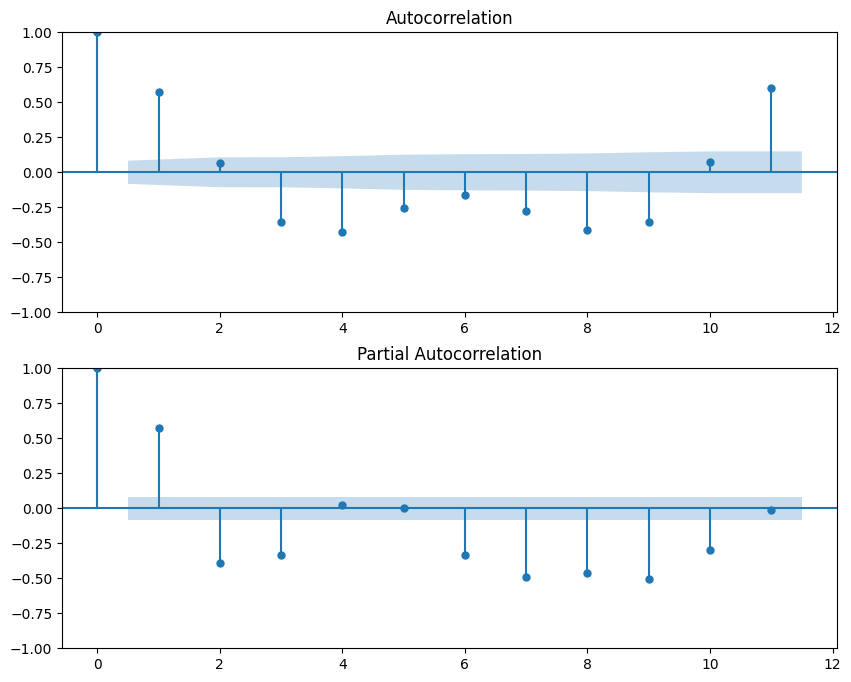

In [367]:
fig = plt.figure(figsize=(10, 8))
ax1 = fig.add_subplot(211)
fig = plot_acf(treino, lags=11, ax=ax1)
ax2 = fig.add_subplot(212)
fig = plot_pacf(treino, lags=11, ax=ax2)

In [368]:
ar_mod_f2 = AutoReg(treino, 10, old_names=False).fit()
print(ar_mod_f2.summary())

                            AutoReg Model Results                             
Dep. Variable:                   TEMP   No. Observations:                  559
Model:                    AutoReg(10)   Log Likelihood                -993.284
Method:               Conditional MLE   S.D. of innovations              1.477
Date:                Mon, 05 May 2025   AIC                           2010.569
Time:                        15:08:09   BIC                           2062.266
Sample:                    12-01-1966   HQIC                          2030.773
                         - 08-01-2012                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        111.9748      3.244     34.518      0.000     105.617     118.333
TEMP.L1       -0.3349      0.037     -9.170      0.000      -0.406      -0.263
TEMP.L2       -0.3242      0.030    -10.926      0.0

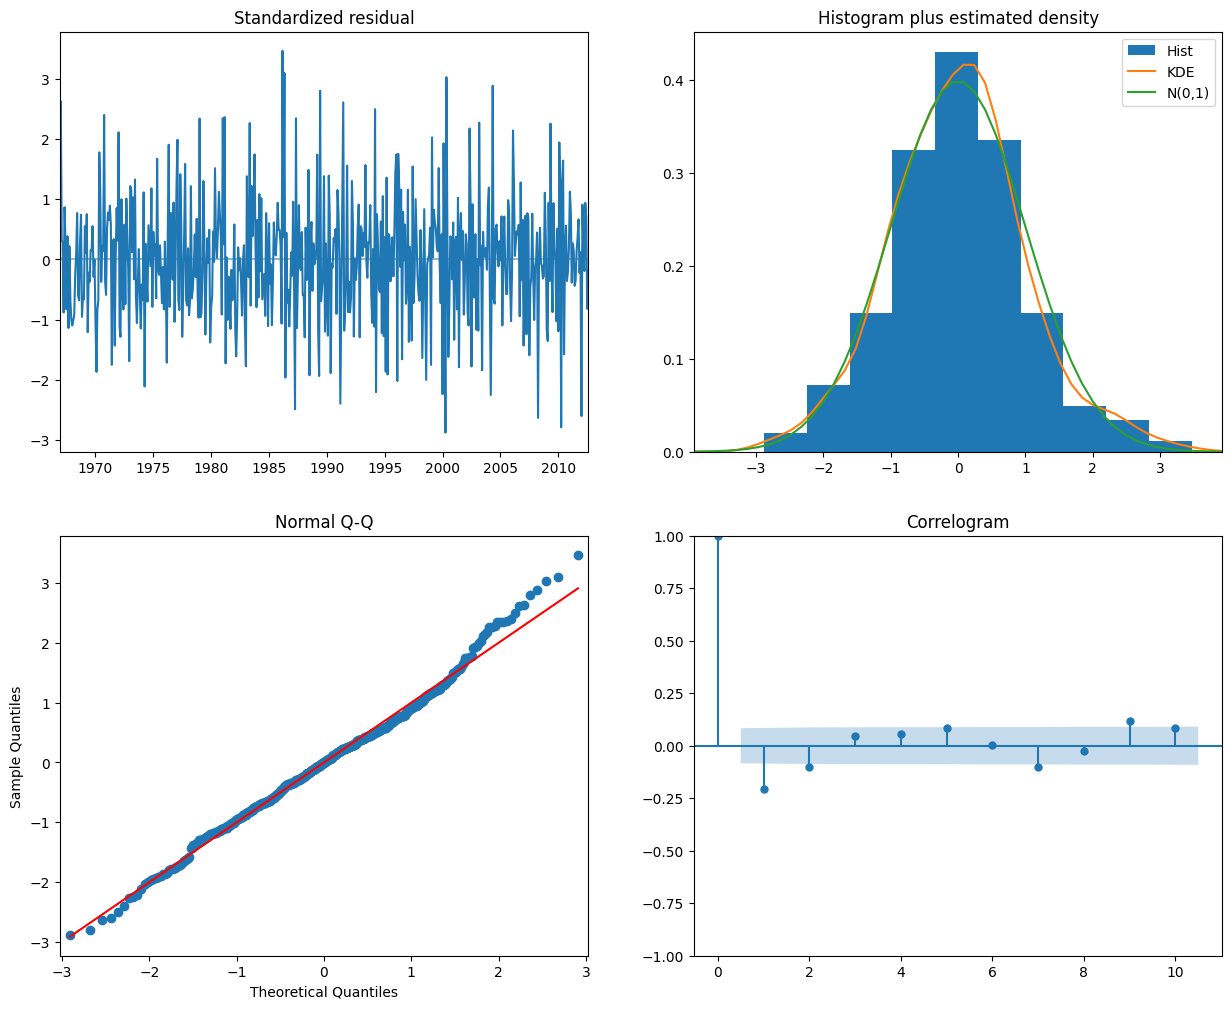

In [369]:
ar_mod_f2.plot_diagnostics(figsize=(15,12))
plt.show()

## **Autoregressive Moving Average (ARMA) Model**  

The **ARMA (Autoregressive Moving Average)** model is a classic time series forecasting method that combines two components:  

1. **AR (Autoregressive)** → Uses past values of the series.  
2. **MA (Moving Average)** → Uses past forecast errors.  

### Mathematical Formulation (ARMA(p, q)) 
An ARMA model of order (*p*, *q*) is defined as:  

\[
X_t = c + \underbrace{\phi_1 X_{t-1} + \phi_2 X_{t-2} + \dots + \phi_p X_{t-p}}_{\text{AR(p)}} + \underbrace{\epsilon_t + \theta_1 \epsilon_{t-1} + \theta_2 \epsilon_{t-2} + \dots + \theta_q \epsilon_{t-q}}_{\text{MA(q)}}
\]  

Where:  
- \(X_t\) = Value at time \(t\)  
- \(c\) = Constant term  
- \(\phi_1, \dots, \phi_p\) = Autoregressive (AR) coefficients  
- \(\theta_1, \dots, \theta_q\) = Moving average (MA) coefficients  
- \(\epsilon_t\) = White noise error term  

### Key Assumptions 
1. **Stationarity Required** → The time series must be stationary (no trend/seasonality).  
2. **No Autocorrelation in Residuals** → Errors should be random (no hidden patterns).  

### How to Determine Orders (p, q)?  
- **ACF (Autocorrelation Function)** → Helps identify MA(*q*) order (cuts off after lag *q*).  
- **PACF (Partial Autocorrelation Function)** → Helps identify AR(*p*) order (cuts off after lag *p*).  

### When to Use ARMA?  
✔️ **Stationary data** (no trend/seasonality).  
✔️ **Short-term forecasts** (e.g., stock prices, temperature).  
❌ **Not suitable for non-stationary data** (use ARIMA with differencing).  

### Limitations 
- Requires **manual selection** of *p* and *q*.  
- Fails if data has **trends** (use ARIMA) or **seasonality** (use SARIMA).  

Need help selecting the right (*p*, *q*) for your data?

In [370]:
from statsmodels.tsa.arima.model import ARIMA

arma_mod = ARIMA(treino, order = (10,0,1)).fit()
print(arma_mod.summary())

                               SARIMAX Results                                
Dep. Variable:                   TEMP   No. Observations:                  559
Model:                ARIMA(10, 0, 1)   Log Likelihood                -988.512
Date:                Mon, 05 May 2025   AIC                           2003.023
Time:                        15:08:11   BIC                           2059.263
Sample:                    02-01-1966   HQIC                          2024.985
                         - 08-01-2012                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         19.9727      0.008   2364.809      0.000      19.956      19.989
ar.L1         -0.0891      0.058     -1.542      0.123      -0.202       0.024
ar.L2         -0.3211      0.034     -9.505      0.0

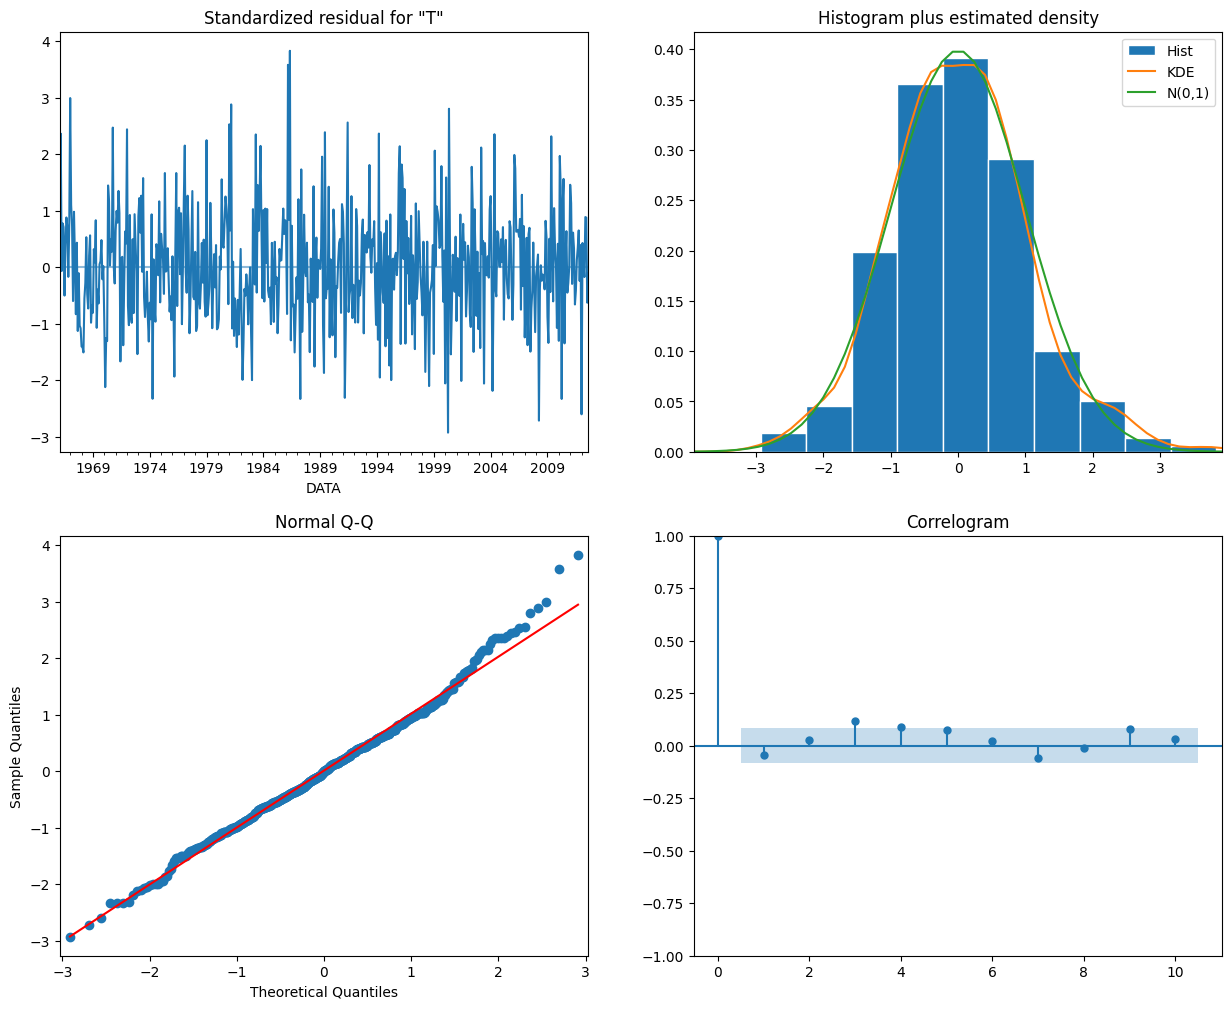

In [371]:
arma_mod.plot_diagnostics(figsize=(15, 12))
plt.show()

### Parameters

In [372]:
import itertools
import warnings
warnings.filterwarnings('ignore')

def grid_arima(p_inicial, p_final, q_inicial, q_final, d_valores, treino):
  # Definindo os parâmetros
  p_params = range(p_inicial, p_final)
  q_params = range(q_inicial, q_final)
  d_params = [d_valores]

  # Gerando todas as combinações possíveis usando product
  combinacoes = list(itertools.product(p_params, d_params, q_params))

  aic_grid = dict()
  # Treinando o modelo e salvando todas combinações
  for order in combinacoes:
    try:
      model = ARIMA(treino, order = order).fit()
      aic_grid[order] = list()
      aic_grid[order].append((model.aic if model.aic else float('inf')))
    except:
      continue
  return aic_grid, min(aic_grid, key=lambda x: aic_grid[x][0])

In [373]:
aic_arma = grid_arima(10,25,1,3,0,treino)

In [374]:
aic_arma[0]

{(10, 0, 1): [2003.0234275792718],
 (10, 0, 2): [1997.3224731747368],
 (11, 0, 1): [1965.5684359712304],
 (11, 0, 2): [1968.1620640082983],
 (12, 0, 1): [1966.9155886891656],
 (12, 0, 2): [1984.7789799166228],
 (13, 0, 1): [1966.8304724402701],
 (13, 0, 2): [1973.036368624049],
 (14, 0, 1): [1968.0446318024606],
 (14, 0, 2): [1970.5204456519168],
 (15, 0, 1): [2020.9131715508163],
 (15, 0, 2): [1973.6454324561107],
 (16, 0, 1): [2022.1565578470015],
 (16, 0, 2): [1970.0210156147086],
 (17, 0, 1): [2024.445334760925],
 (17, 0, 2): [1959.367157770569],
 (18, 0, 1): [2021.00322251909],
 (18, 0, 2): [1961.310874728899],
 (19, 0, 1): [2013.3602268321056],
 (19, 0, 2): [1962.1484664487946],
 (20, 0, 1): [1972.4286057814447],
 (20, 0, 2): [1958.5594445789015],
 (21, 0, 1): [1953.8086341006192],
 (21, 0, 2): [1949.5125072270419],
 (22, 0, 1): [1947.903568371778],
 (22, 0, 2): [1941.6595581085703],
 (23, 0, 1): [1939.7381700558185],
 (23, 0, 2): [1942.6789286674298],
 (24, 0, 1): [1937.24157053

In [375]:
aic_arma[1]

(24, 0, 2)

In [376]:
arma_mod_ot = ARIMA(treino, order=aic_arma[1]).fit()
print(arma_mod_ot.summary())

                               SARIMAX Results                                
Dep. Variable:                   TEMP   No. Observations:                  559
Model:                ARIMA(24, 0, 2)   Log Likelihood                -934.107
Date:                Mon, 05 May 2025   AIC                           1924.215
Time:                        15:09:43   BIC                           2045.347
Sample:                    02-01-1966   HQIC                          1971.518
                         - 08-01-2012                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         19.9728      0.004   4634.688      0.000      19.964      19.981
ar.L1         -0.4116      0.318     -1.296      0.195      -1.034       0.211
ar.L2          0.1878      0.130      1.445      0.1

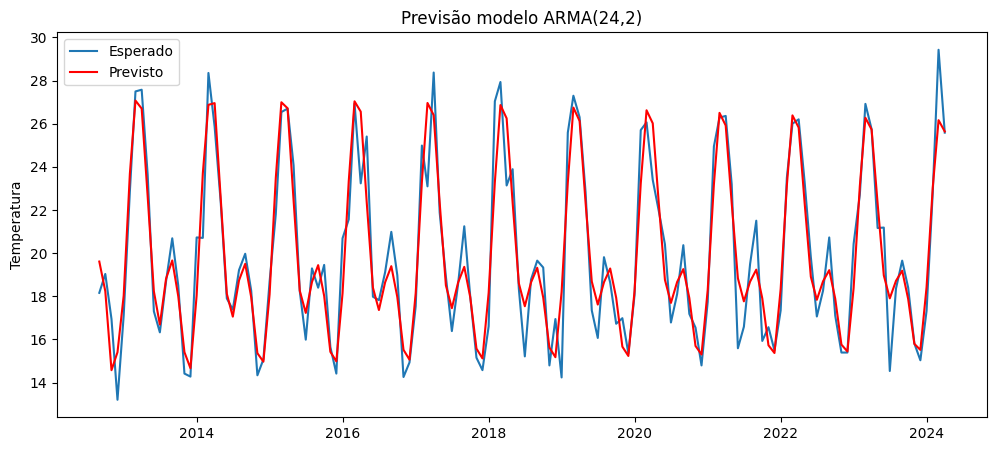


Métricas:

MAE: 1.0653566997653663
MSE: 1.9799301483242016


In [377]:
plot_prev(treino, teste, arma_mod_ot, 'ARMA(24,2)')

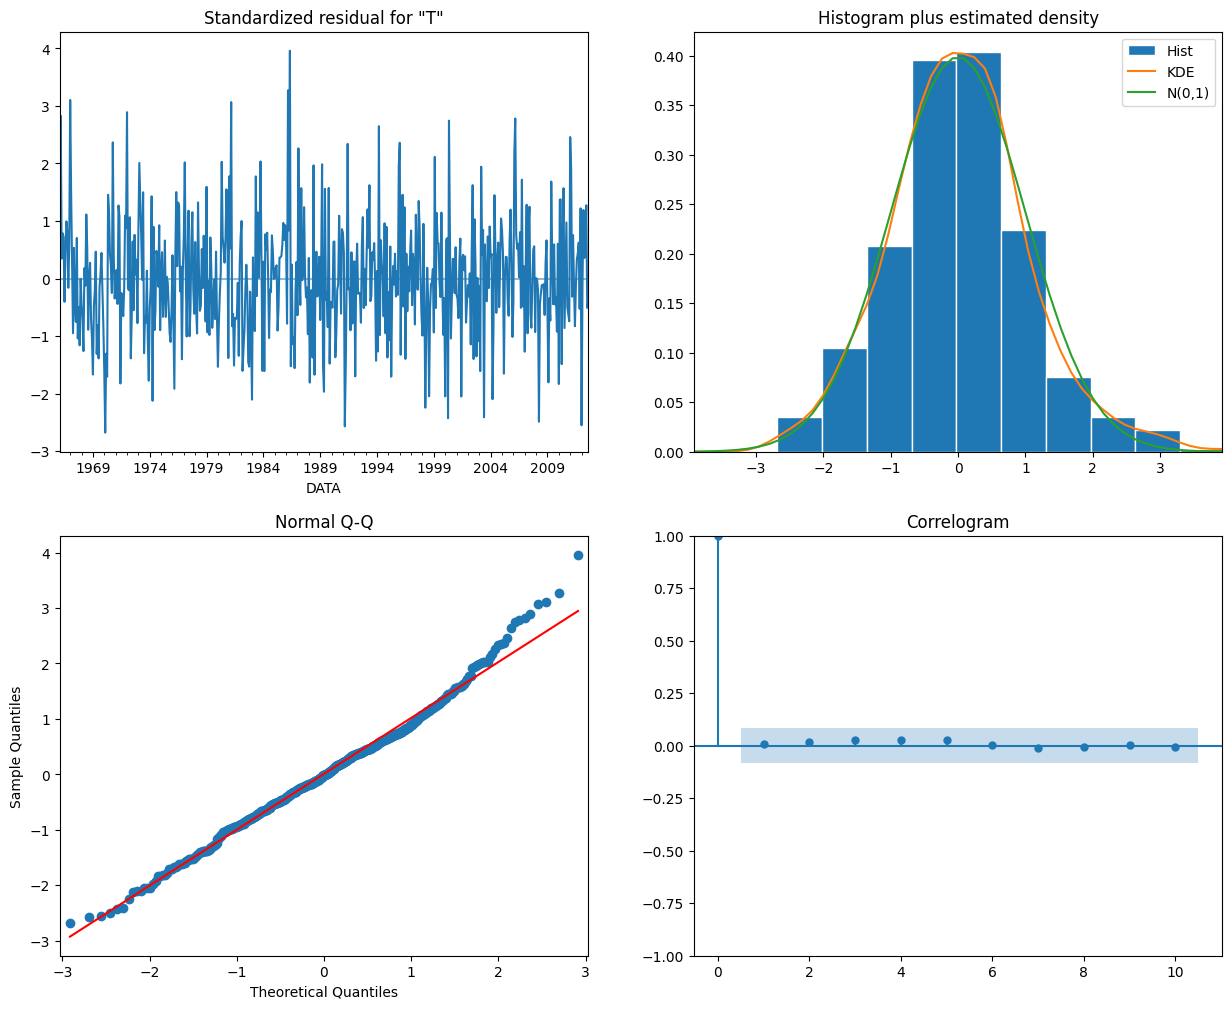

In [378]:
arma_mod_ot.plot_diagnostics(figsize=(15,12))
plt.show()

# Farm III

![Alt text: Imagem de uma fazenda com plantações de arroz](https://github.com/Mirlaa/s-ries-temporais-statsmodels/blob/main/imagens/Fazenda%203.png?raw=true)

In [379]:
df_f3 = pd.read_csv(dados_f3)
df_f3

,DATA,TEMP
0,1965-09-01,33.30
1,1965-10-01,32.88
2,1965-11-01,30.28
3,1965-12-01,30.42
4,1966-01-01,30.39
...,...,...
699,2023-12-01,31.72
700,2024-01-01,32.22
701,2024-02-01,32.29
702,2024-03-01,29.60


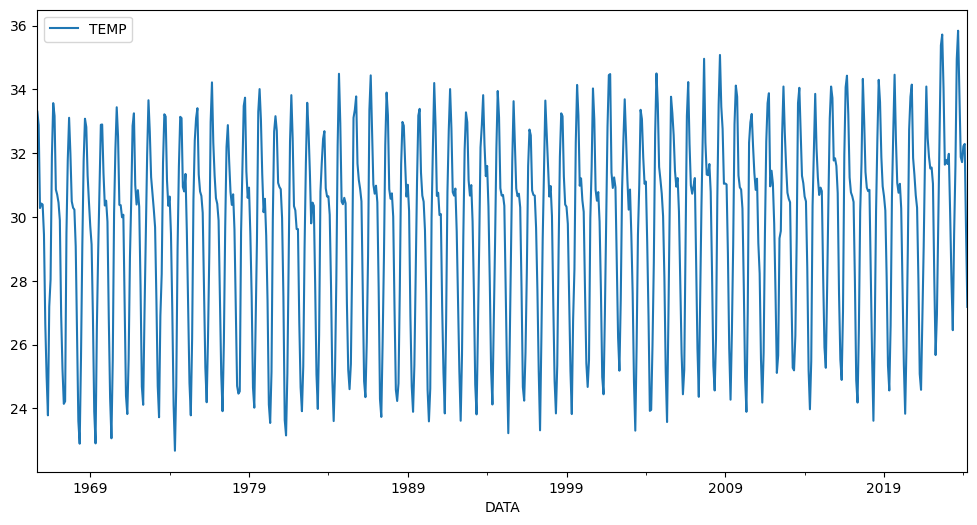

In [380]:
df_f3['DATA'] = pd.to_datetime(df_f3['DATA'], format='%Y-%m-%d')
df_f3.set_index(['DATA'], inplace=True, drop=True)
fig = df_f3.plot(figsize=(12, 6))

In [381]:
estac(df_f3)

Valor-p do Teste ADF: 0.0669
Não rejeitar a Hipótese Nula: a série não é estacionária

Valor-p do Teste KPSS: 0.0100
Rejeitar a Hipótese Nula: a série não é estacionária



In [382]:
df_f3.diff(1)

,TEMP
DATA,
1965-09-01,NaN
1965-10-01,-0.42
1965-11-01,-2.60
1965-12-01,0.14
1966-01-01,-0.03
...,...
2023-12-01,-0.16
2024-01-01,0.50
2024-02-01,0.07


In [383]:
estac(df_f3.diff(1).iloc[1:])

Valor-p do Teste ADF: 0.0000
Rejeitar a Hipótese Nula: a série é estacionária

Valor-p do Teste KPSS: 0.1000
Não rejeitar a Hipótese Nula: a série é estacionária



## **Autoregressive Integrated Moving Average (ARIMA) Model**  

The **ARIMA model** is a powerful time series forecasting method that generalizes ARMA models by **adding differencing to handle non-stationary data**. It combines:  

1. **AR (Autoregressive)** → Uses past values.  
2. **I (Integrated)** → Uses differencing to remove trends.  
3. **MA (Moving Average)** → Uses past forecast errors.  

### Mathematical Formulation (ARIMA(p, d, q)) 

An ARIMA model of order (*p*, *d*, *q*) is defined as:  

\[
(1 - \phi_1 L - \dots - \phi_p L^p)(1 - L)^d X_t = c + (1 + \theta_1 L + \dots + \theta_q L^q) \epsilon_t
\]  

Where:  
- \(X_t\) = Value at time \(t\)  
- \(L\) = Lag operator (e.g., \(L X_t = X_{t-1}\))  
- \(\phi_1, \dots, \phi_p\) = Autoregressive (AR) coefficients  
- \(\theta_1, \dots, \theta_q\) = Moving average (MA) coefficients  
- \(d\) = Differencing order (makes series stationary)  
- \(\epsilon_t\) = White noise error term  

### Key Steps for ARIMA Modeling

1. **Check Stationarity**  
   - Use **ADF test** (Augmented Dickey-Fuller).  
   - If non-stationary, apply differencing (*d* > 0).  

2. **Determine Orders (p, q)**  
   - **ACF/PACF plots** → Identify AR(*p*) and MA(*q*) terms.  
   - **AutoARIMA** (automated selection).  

3. **Fit Model & Validate**  
   - Ensure residuals are **white noise** (no patterns).  

### When to Use ARIMA?
✔️ **Non-stationary data** (with trends but no seasonality).  
✔️ **Short-to-medium-term forecasts** (e.g., sales, energy demand).  
❌ **Not for seasonal data** (use **SARIMA** instead).  


### Limitations 
- Requires **manual tuning** of (*p*, *d*, *q*).  
- Struggles with **strong seasonality** or **external variables**.

In [384]:
divisao = int(len(df_f3) * 0.8)

treino = df_f3.iloc[:divisao].asfreq('MS')
teste = df_f3.iloc[divisao:].asfreq('MS')

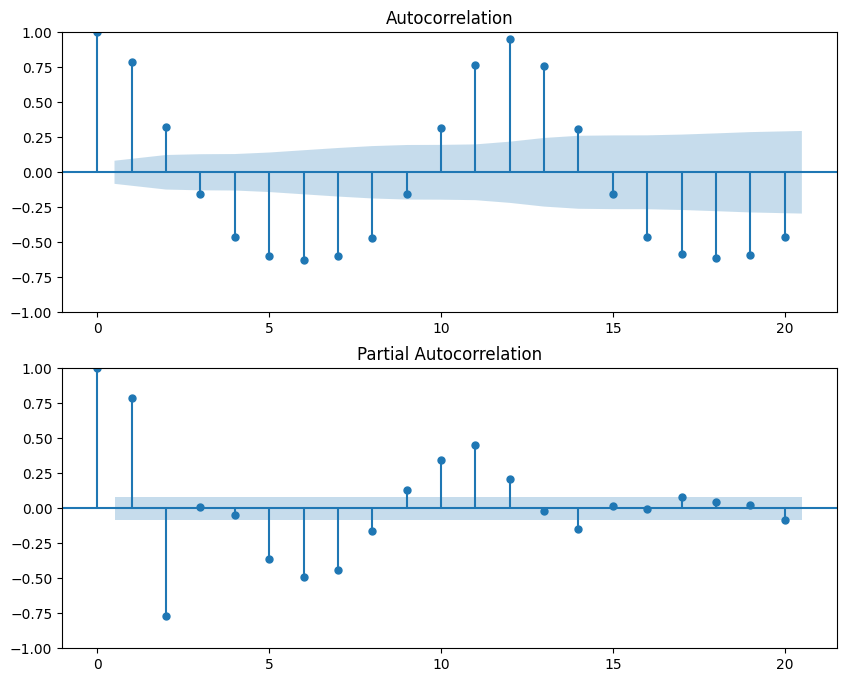

In [385]:
fig = plt.figure(figsize=(10, 8))
ax1 = fig.add_subplot(211)
fig = plot_acf(treino, lags=20, ax=ax1)
ax2 = fig.add_subplot(212)
fig = plot_pacf(treino, lags=20, ax=ax2)

In [386]:
arima_mod = ARIMA(treino, order=(14,1,2)).fit()
print(arima_mod.summary())

                               SARIMAX Results                                
Dep. Variable:                   TEMP   No. Observations:                  563
Model:                ARIMA(14, 1, 2)   Log Likelihood                -544.683
Date:                Mon, 05 May 2025   AIC                           1123.365
Time:                        15:09:46   BIC                           1197.001
Sample:                    09-01-1965   HQIC                          1152.114
                         - 07-01-2012                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.4300      0.347     -1.239      0.215      -1.110       0.250
ar.L2          0.1418      0.368      0.386      0.700      -0.579       0.862
ar.L3         -0.2514      0.297     -0.848      0.3

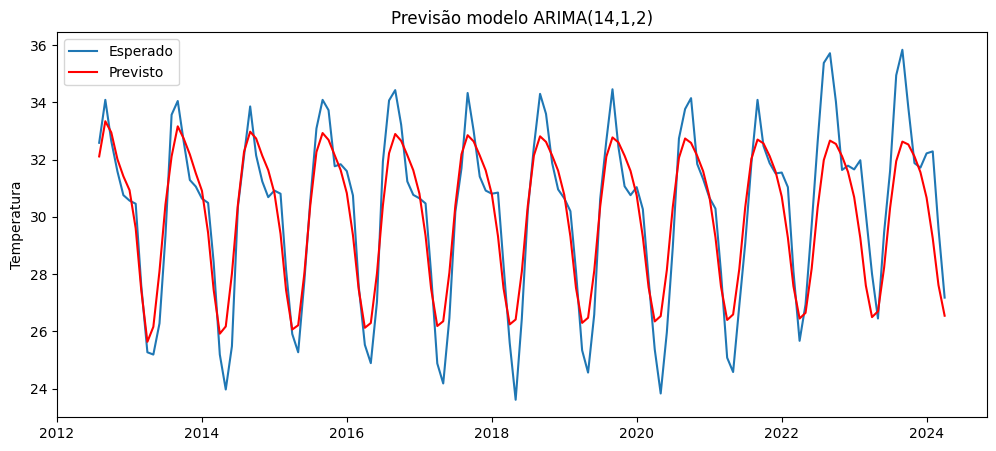


Métricas:

MAE: 0.9939425675614161
MSE: 1.5718279647716866


In [387]:
plot_prev(treino, teste, arima_mod, 'ARIMA(14,1,2)')

### Paramenters

In [388]:
aic_arima = grid_arima(14,25,1,3,1,treino)

In [389]:
aic_arima[1]

(24, 1, 2)

In [390]:
arima_mod_ot = ARIMA(treino, order = (24, 1, 2)).fit()
print(arima_mod_ot.summary())

                               SARIMAX Results                                
Dep. Variable:                   TEMP   No. Observations:                  563
Model:                ARIMA(24, 1, 2)   Log Likelihood                -504.872
Date:                Mon, 05 May 2025   AIC                           1063.744
Time:                        15:10:35   BIC                           1180.695
Sample:                    09-01-1965   HQIC                          1109.403
                         - 07-01-2012                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.4510      0.153     -2.951      0.003      -0.750      -0.151
ar.L2          0.1552      0.085      1.837      0.066      -0.010       0.321
ar.L3         -0.1447      0.070     -2.063      0.0

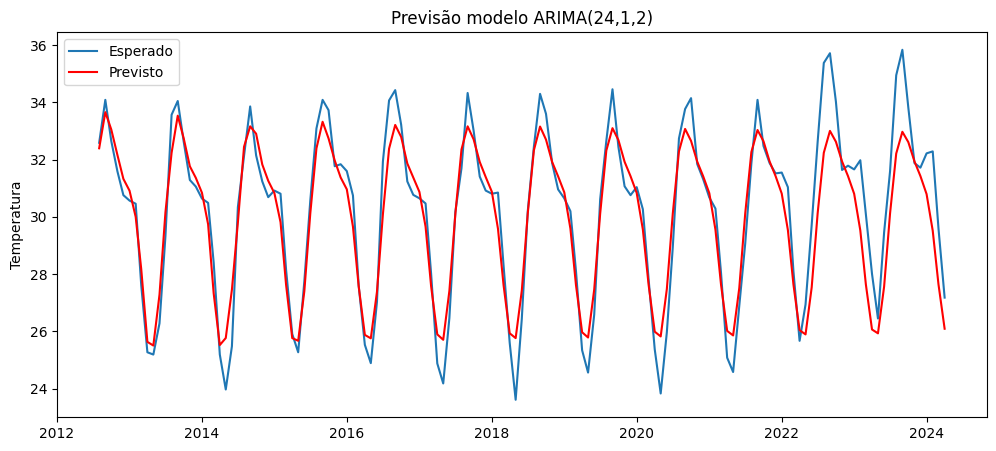


Métricas:

MAE: 0.8332336258629346
MSE: 1.161325325172755


In [391]:
plot_prev(treino, teste, arima_mod_ot, 'ARIMA(24,1,2)')

### **Sazonality**

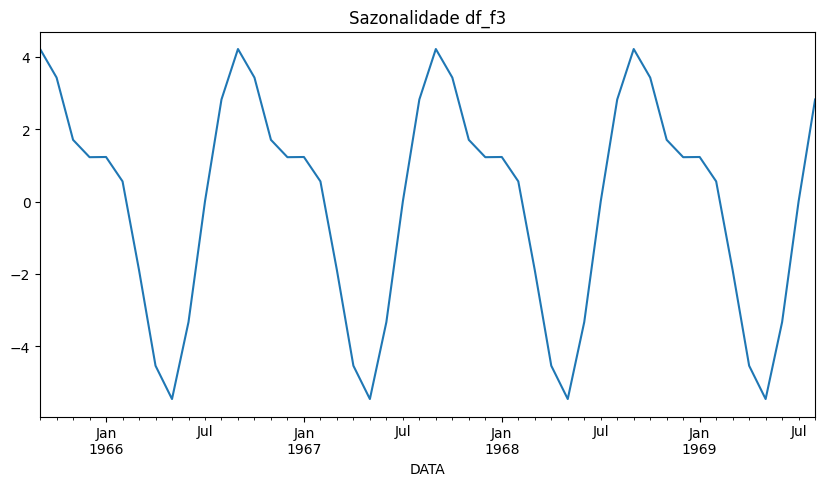

In [392]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomposicao_df = seasonal_decompose(df_f3)

fig = plt.figure(figsize=(10,5))
decomposicao_df.seasonal.iloc[:48].plot(title='Sazonalidade df_f3')
plt.show()

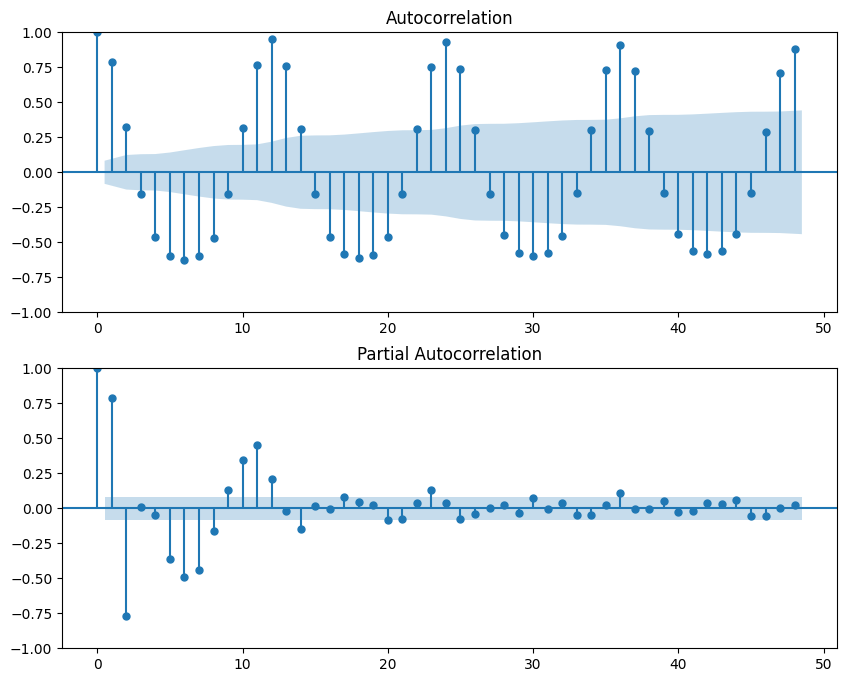

In [393]:
fig = plt.figure(figsize=(10, 8))
ax1 = fig.add_subplot(211)
fig = plot_acf(treino, lags=48, ax=ax1)
ax2 = fig.add_subplot(212)
fig = plot_pacf(treino, lags=48, ax=ax2)

## **Seasonal Autoregressive Integrated Moving Average (SARIMA) Model**  

The **SARIMA model** extends ARIMA by explicitly modeling **seasonal patterns** in time series data. It combines:  

1. **Non-seasonal components (ARIMA)** → Handles trends and short-term dependencies.  
2. **Seasonal components** → Captures repeating patterns at fixed intervals.  

### Mathematical Formulation (SARIMA(p,d,q)(P,D,Q)[S]) 

\[
(1 - \phi_1 L - \dots - \phi_p L^p)(1 - \Phi_1 L^S - \dots - \Phi_P L^{P \cdot S})(1 - L)^d (1 - L^S)^D X_t = c + (1 + \theta_1 L + \dots + \theta_q L^q)(1 + \Theta_1 L^S + \dots + \Theta_Q L^{Q \cdot S}) \epsilon_t
\]

Where:  
- **Non-seasonal part**:  
  - \(p\) = AR order, \(d\) = differencing, \(q\) = MA order  
- **Seasonal part**:  
  - \(P\) = Seasonal AR order, \(D\) = seasonal differencing, \(Q\) = seasonal MA order  
  - \(S\) = Seasonality period (e.g., 12 for monthly data)  
- \(L\) = Lag operator (e.g., \(L^S X_t = X_{t-S}\))  

### Key Steps for SARIMA Modeling

1. **Identify Seasonality Period (S)**  
   - E.g., 12 for monthly data, 4 for quarterly data.  

2. **Make Data Stationary**  
   - Apply **non-seasonal differencing (d)** and **seasonal differencing (D)**.  

3. **Determine Orders (p, q, P, Q)**  
   - Use **ACF/PACF plots** at lags \(S, 2S, \dots\).  
   - **AutoARIMA** for automated selection.  

4. **Fit Model & Validate Residuals**  
   - Residuals should be **white noise** (no patterns).  

### When to Use SARIMA?  
✔ **Data with trends + seasonality** (e.g., retail sales, energy demand).  
✔ **Fixed-interval patterns** (e.g., monthly, quarterly).  
❌ **Irregular seasonality** (use **TBATS** or **Prophet**).  

### Limitations  
- Requires **manual tuning** of \((p,d,q)(P,D,Q)[S]\).  
- Assumes **strict periodicity** (fails if seasonality changes over time).  

### SARIMA vs. ARIMA* 
| **Feature**       | **ARIMA**          | **SARIMA**         |  
|-------------------|--------------------|--------------------|  
| **Handles Seasonality** | ❌ No | ✔️ Yes |  
| **Model Complexity** | Simpler \((p,d,q)\) | More complex \((p,d,q)(P,D,Q)[S]\) |  
| **Use Case**       | Trend-only data    | Trend + seasonal data |  

In [394]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

sarima_mod = SARIMAX(treino, order = (11,1,2), seasonal_order = (2,1,1,12)).fit()
print(sarima_mod.summary())

                                       SARIMAX Results                                       
Dep. Variable:                                  TEMP   No. Observations:                  563
Model:             SARIMAX(11, 1, 2)x(2, 1, [1], 12)   Log Likelihood                -456.394
Date:                               Mon, 05 May 2025   AIC                            946.787
Time:                                       15:10:46   BIC                           1020.056
Sample:                                   09-01-1965   HQIC                           975.419
                                        - 07-01-2012                                         
Covariance Type:                                 opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.5655      0.147     -3.838      0.000      -0.854      -0.277
ar.L2      

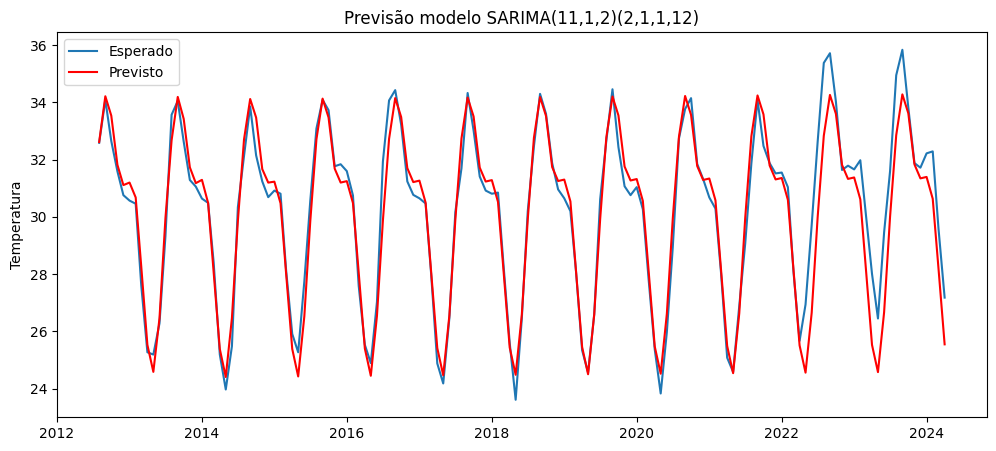


Métricas:

MAE: 0.5943370837576684
MSE: 0.7495281810978136


In [395]:
plot_prev(treino,teste,sarima_mod,'SARIMA(11,1,2)(2,1,1,12)')

# Previsões das Fazendas

Temos 3 modelos para 3 conjuntos de dados sobre as temperaturas das fazendas

* Fazenda 1 modelo $AR(34)$
* Fazenda 2 modelo $ARMA(24,2)$
* Fazenda 3 modelo $SARIMA(11, 1, 1)\times (2, 1, 1, 12)$

```Python
mod_f1 = AutoReg(df_f1, 34, old_names=False).fit()
mod_f2 = ARIMA(df_f2, order=(24,0,2)).fit()
mod_f3 = SARIMAX(df_f3, order=(11, 1, 1), seasonal_order=(2, 1, 1, 12)).fit()
```

In [396]:
mod_f1 = AutoReg(df_f1, 34, old_names=False).fit()
mod_f2 = ARIMA(df_f2, order=(24,0,2)).fit()
mod_f3 = SARIMAX(df_f3, order=(11, 1, 1), seasonal_order=(2, 1, 1, 12)).fit()

In [397]:
previsao_f1 = mod_f1.predict(len(df_f1), len(df_f1) + 35, dynamic=False)
previsao_f2 = mod_f2.predict(len(df_f2), len(df_f2) + 35, dynamic=False)
previsao_f3 = mod_f3.predict(len(df_f3), len(df_f3) + 35, dynamic=False)

In [398]:
previsao_f1

2024-05-01    23.754813
2024-06-01    25.073979
2024-07-01    25.745189
2024-08-01    25.482945
2024-09-01    24.688088
2024-10-01    23.396004
2024-11-01    21.987786
2024-12-01    20.884098
2025-01-01    20.462515
2025-02-01    20.671650
2025-03-01    21.437362
2025-04-01    22.747177
2025-05-01    24.272593
2025-06-01    25.631728
2025-07-01    26.151243
2025-08-01    25.772192
2025-09-01    24.810964
2025-10-01    23.402365
2025-11-01    21.817364
2025-12-01    20.637679
2026-01-01    20.235018
2026-02-01    20.583082
2026-03-01    21.474468
2026-04-01    22.864869
2026-05-01    24.469955
2026-06-01    25.757861
2026-07-01    26.256951
2026-08-01    25.993914
2026-09-01    25.070860
2026-10-01    23.642252
2026-11-01    22.077607
2026-12-01    20.899951
2027-01-01    20.356688
2027-02-01    20.564789
2027-03-01    21.397561
2027-04-01    22.680671
Freq: MS, dtype: float64